____
# Spatial filtering of SWOT


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, coloc_swot, rotate_ggd, add_grid_metrics

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

___________
# CHOOSE

_______
# Data

In [9]:
dfs = browse_swot_250().reset_index()
dss = xr.open_dataset(dfs.file.iloc[10])
dss = add_grid_metrics(dss)
sla = dss.duacs_ssha_karin_2_calibrated

# See Windows and frequency response

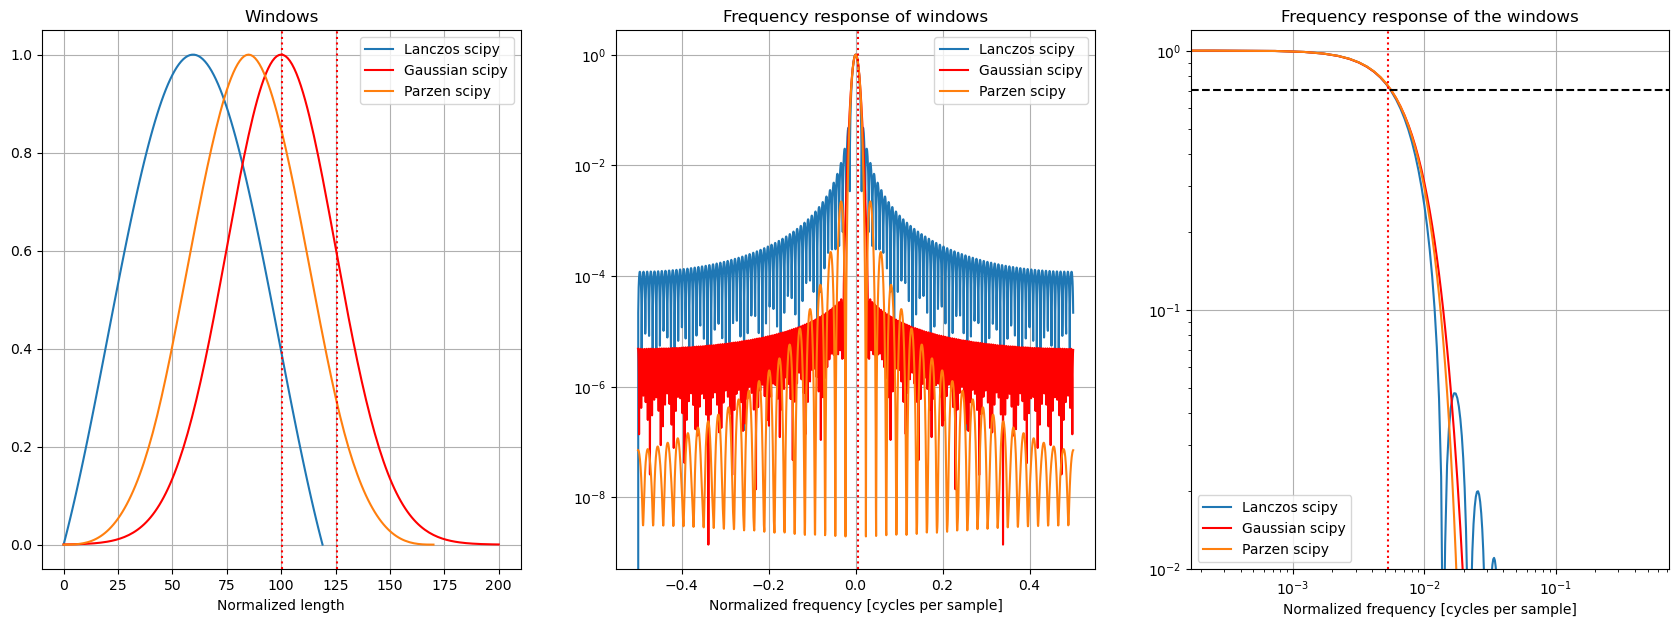

In [161]:
import scipy.signal.windows as wdw
from scipy.fft import fft, fftfreq
dx = 100#m


# Gaussian
lambda_cutoff = 3e3/dx
sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
Mg = 2 * round(4*sigma_cutoff)+1

#Parzen 
Mp = int(lambda_cutoff*0.9104*2*np.pi)

lanczos = wdw.lanczos(Mp//np.sqrt(2))#int(cutoff/dx))
parzen = wdw.parzen(Mp)
#lanczos = lanczos/sum(lanczos)
gaussian = wdw.gaussian(Mg,  std = sigma_cutoff)
#gaussian = gaussian/sum(gaussian)

def diff_lanczos(M):
    n=np.arange(M)
    x = 2*n/(M-1) -1
    l = 2/(M-1)*(np.cos(np.pi*x)/x - np.sin(np.pi*x)/(np.pi*x**2))
    return l

def comp_lanczos( M) :
    n=np.arange(M)
    x = 2*n/(M-1)-1
    l = np.sin(np.pi*x)/np.pi/x
    return l

def frequency_response(window):
    A = fft(window, 2048) / (len(window)/2.0)
    freq = np.linspace(-0.5, 0.5, len(A))
    #response = 20 * np.log10(np.abs(fftshift(A / abs(A).max())))
    response = np.abs(fftshift(A / abs(A).max()))
    return freq, response

fig, axs = plt.subplots(1, 3, figsize=(21, 7))
ax=axs[0]
ax.plot(np.arange(len(lanczos)), lanczos, label = 'Lanczos scipy')
ax.plot(np.arange(len(gaussian)), gaussian, label = 'Gaussian scipy', c='r')
ax.plot(np.arange(len(parzen)), parzen, label = 'Parzen scipy')
#ax.plot(n, diff_lanczos(M), label = 'Diff Lanczos')
#ax.plot(n, comp_lanczos(M), label = 'Lanczos maison', ls='--')
ax.grid()
ax.legend()
ax.axvline(Mg/2, c='r', ls=':')
ax.axvline(Mg/2 + sigma_cutoff, c='r', ls=':')
ax.set_title('Windows')
ax.set_xlabel('Normalized length')

ax=axs[1]
ax.plot(*frequency_response(lanczos), label = 'Lanczos scipy')
ax.plot(*frequency_response(gaussian), label = 'Gaussian scipy',  c='r')
ax.plot(*frequency_response(parzen), label = 'Parzen scipy')
ax.grid()
ax.legend()
ax.axvline(1/lambda_cutoff/np.pi/2, c='r', ls=':')
ax.set_title("Frequency response of windows")
ax.set_xlabel("Normalized frequency [cycles per sample]")
ax.set_yscale('log')

ax=axs[2]
ax.plot(*frequency_response(lanczos), label = 'Lanczos scipy')
ax.plot(*frequency_response(gaussian), label = 'Gaussian scipy', c='r')
ax.plot(*frequency_response(parzen), label = 'Parzen scipy')
ax.axvline(1/lambda_cutoff/np.pi/2, c='r', ls=':')
ax.axhline(1/np.sqrt(2), c='k', ls='--')
ax.grid()
ax.legend()
ax.set_ylim(1e-2,1.2)
#ax.set_xlim(-2/sigma_cutoff/np.pi/2, 2/sigma_cutoff/np.pi/2)
ax.set_title("Frequency response of the windows")
ax.set_xlabel("Normalized frequency [cycles per sample]")
ax.set_yscale('log')
ax.set_xscale('log')


# Snapshots

In [162]:
from scipy.ndimage import convolve1d

fl = xr.DataArray(convolve1d(convolve1d(sla.interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines'), lanczos/sum(lanczos), axis=0), lanczos/sum(lanczos), axis=1), dims=sla.dims)
fg = xr.DataArray(convolve1d(convolve1d(sla.interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines'), gaussian/sum(gaussian), axis=0), gaussian/sum(gaussian), axis=1), dims=sla.dims)
from scipy.ndimage import gaussian_filter
fgp = xr.DataArray(gaussian_filter(sla.interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines'), sigma=cutoff/dx, order=[0,0]), dims=sla.dims)

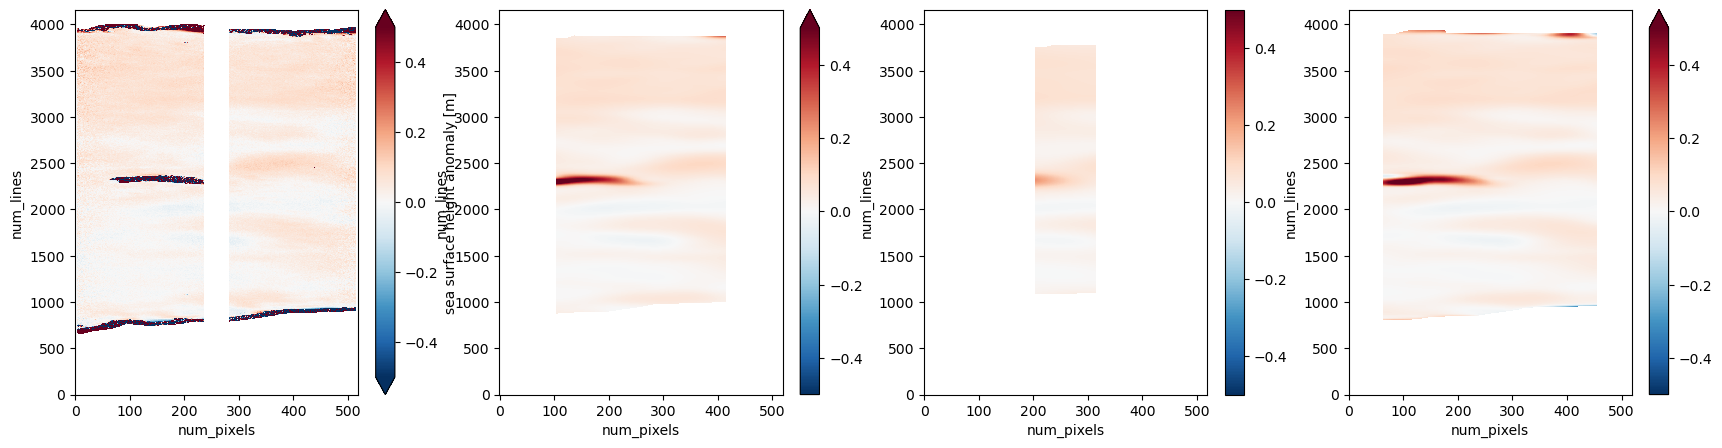

In [163]:
fig, axs = plt.subplots(1,4, figsize=(21, 5))
sla.plot(vmax=0.5, ax=axs[0])
fg.plot(vmax=0.5, ax=axs[1])
fgp.plot(vmax=0.5, ax=axs[2])
fl.plot(vmax=0.5, ax=axs[3])